# 03 - MediaPipe Face Mesh Lip Landmark & Crop Experiment (96×96 RGB)
## Tai Phake Visual Speech Recognition (VSR) Project

**Objective**: Implement and evaluate Google MediaPipe Face Mesh for facial landmark detection and lip region-of-interest (ROI) extraction across all 30 speakers ($s_1 \dots s_{30}$) and 11 digit classes ($d_0 \dots d_{10}$) in the Tai Phake dataset ($330$ utterances, $13,610$ raw frames).

---

### Key Requirements & Pipeline Formulation:
1. **Face Mesh Landmark Extraction**: Uses MediaPipe's high-density facial landmark topology ($478$ 3D points) to identify the 40 canonical lip contour landmarks (`FACE_LANDMARKS_LIPS`).
2. **Bounding Box with Comfort Margin**: Calculates the minimum bounding box encompassing all 40 lip landmarks, plus a configurable context padding ($P_x = 15\text{ px}, P_y = 10\text{ px}$) to preserve the complete lips and perioral mouth region.
3. **Direct 96×96 RGB Crop**: Extracts the mouth region directly from the source RGB frame and resizes directly to $96\times 96$ pixels using area interpolation (`cv2.INTER_AREA`).
   - **No letterboxing** (no synthetic artificial borders).
   - **No full-face squashing** (strictly isolates the mouth ROI).
   - **Full RGB color preserved**.
4. **Safe Failure Handling**: Frames where no face or mouth can be detected are flagged, recorded in a structured CSV report, and visually archived in `results/mediapipe_preview/failed_detections/`.
5. **Isolation**: Dedicated experiment dataset saved to `data/experiments/mediapipe_lips_dataset_96x96/` leaving existing Dlib datasets untouched.
6. **Visual Inspection**: Multi-utterance contact sheets and side-by-side original-vs-crop comparisons generated in `results/mediapipe_preview/`.

In [1]:
import os
import sys
import time
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import FaceLandmarksConnections

# Project paths
PROJECT_ROOT = Path("..").resolve()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "digit"
if not RAW_DATA_DIR.exists():
    RAW_DATA_DIR = PROJECT_ROOT / "data" / "experiments" / "digit"

OUTPUT_DATASET_DIR = PROJECT_ROOT / "data" / "experiments" / "mediapipe_lips_dataset_96x96"
RESULTS_DIR = PROJECT_ROOT / "results" / "mediapipe_preview"
MODEL_PATH = PROJECT_ROOT / "models" / "mediapipe" / "face_landmarker.task"

# Preprocessing hyperparameters
TARGET_WIDTH = 96
TARGET_HEIGHT = 96
PAD_X = 15  # Horizontal padding in pixels
PAD_Y = 10  # Vertical padding in pixels

print(f"Project Root:          {PROJECT_ROOT}")
print(f"Raw Frames Directory:  {RAW_DATA_DIR}")
print(f"Output Dataset:        {OUTPUT_DATASET_DIR}")
print(f"Results / Preview:     {RESULTS_DIR}")
print(f"MediaPipe Model:       {MODEL_PATH} (Exists: {MODEL_PATH.exists()})")
print(f"MediaPipe Version:     {mp.__version__}")
print(f"OpenCV Version:        {cv2.__version__}")

Project Root:          /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading
Raw Frames Directory:  /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/digit
Output Dataset:        /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/experiments/mediapipe_lips_dataset_96x96
Results / Preview:     /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mediapipe_preview
MediaPipe Model:       /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/models/mediapipe/face_landmarker.task (Exists: True)
MediaPipe Version:     0.10.35
OpenCV Version:        5.0.0


## 1. MediaPipe FaceLandmarker Initialization & Lip Topology

MediaPipe Face Mesh provides 478 high-precision 3D facial landmarks. The canonical lip region is indexed by `FaceLandmarksConnections.FACE_LANDMARKS_LIPS`, which consists of 40 landmark points forming both inner and outer contours of the upper and lower lips.

In [2]:
# Extract 40 canonical lip landmark indices
LIP_CONNECTIONS = FaceLandmarksConnections.FACE_LANDMARKS_LIPS
LIP_LANDMARK_INDICES = sorted(list(set([c.start for c in LIP_CONNECTIONS] + [c.end for c in LIP_CONNECTIONS])))

print(f"Total lip landmark points: {len(LIP_LANDMARK_INDICES)}")
print(f"Indices: {LIP_LANDMARK_INDICES}")

def create_detector(model_asset_path: Path) -> vision.FaceLandmarker:
    """Creates a FaceLandmarker detector using CPU delegate for robust inference."""
    base_options = python.BaseOptions(
        model_asset_path=str(model_asset_path),
        delegate=python.BaseOptions.Delegate.CPU
    )
    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
        num_faces=1
    )
    return vision.FaceLandmarker.create_from_options(options)

detector = create_detector(MODEL_PATH)
print("MediaPipe FaceLandmarker detector initialized successfully.")

Total lip landmark points: 40
Indices: [0, 13, 14, 17, 37, 39, 40, 61, 78, 80, 81, 82, 84, 87, 88, 91, 95, 146, 178, 181, 185, 191, 267, 269, 270, 291, 308, 310, 311, 312, 314, 317, 318, 321, 324, 375, 402, 405, 409, 415]
MediaPipe FaceLandmarker detector initialized successfully.


I0000 00:00:1791043492.996240 22682879 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 11, prefix = pthread-default
W0000 00:00:1791043492.996589 22682879 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1791043493.065172 22682879 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1791043493.066811 22682899 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791043493.071615 22682903 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## 2. Lip Bounding Box Detection & Cropping Functions

Given a raw frame:
1. Detect the face and landmarks using MediaPipe.
2. Query the 40 lip landmarks to compute $[x_{\min}, x_{\max}, y_{\min}, y_{\max}]$.
3. Add comfort margin: $x_1 = \max(0, x_{\min} - P_x)$, $y_1 = \max(0, y_{\min} - P_y)$, $x_2 = \min(W, x_{\max} + P_x)$, $y_2 = \min(H, y_{\max} + P_y)$.
4. Crop directly from the source RGB frame and resize directly to $96\times 96$ pixels.

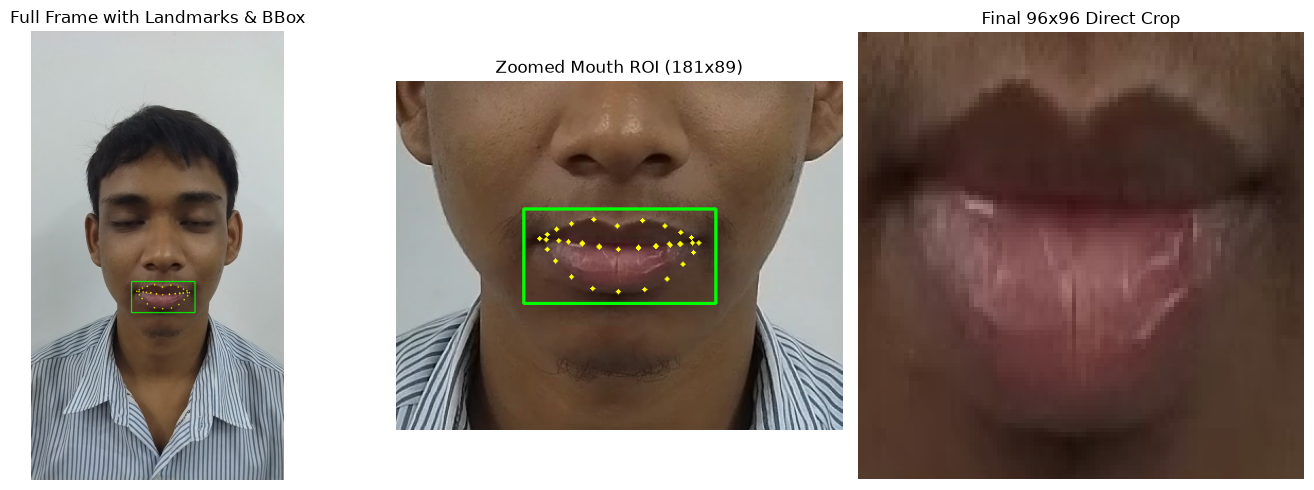

Sample bbox: (285, 713) to (466, 802), Crop shape: (96, 96, 3)


In [3]:
def detect_mouth_bbox(
    img_bgr: np.ndarray,
    detector: vision.FaceLandmarker,
    pad_x: int = PAD_X,
    pad_y: int = PAD_Y,
) -> Tuple[Optional[Tuple[int, int, int, int]], Optional[np.ndarray], Optional[str]]:
    """
    Detects face mesh landmarks and extracts the mouth bounding box with margin.
    """
    h, w = img_bgr.shape[:2]
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    
    try:
        detection_result = detector.detect(mp_img)
    except Exception as e:
        return None, None, f"Detection exception: {e}"
    
    if not detection_result.face_landmarks:
        return None, None, "No face detected"
    
    landmarks = detection_result.face_landmarks[0]
    lip_pts = np.array(
        [[landmarks[idx].x * w, landmarks[idx].y * h] for idx in LIP_LANDMARK_INDICES],
        dtype=np.float32
    )
    
    x_min = np.min(lip_pts[:, 0])
    x_max = np.max(lip_pts[:, 0])
    y_min = np.min(lip_pts[:, 1])
    y_max = np.max(lip_pts[:, 1])
    
    x1 = max(0, int(round(x_min - pad_x)))
    y1 = max(0, int(round(y_min - pad_y)))
    x2 = min(w, int(round(x_max + pad_x)))
    y2 = min(h, int(round(y_max + pad_y)))
    
    if (x2 - x1) <= 0 or (y2 - y1) <= 0:
        return None, lip_pts, f"Invalid crop dimensions: ({x1}, {y1}) to ({x2}, {y2})"
    
    return (x1, y1, x2, y2), lip_pts, None


def extract_and_resize_lip(
    img_bgr: np.ndarray,
    bbox: Tuple[int, int, int, int],
    target_w: int = TARGET_WIDTH,
    target_h: int = TARGET_HEIGHT,
) -> np.ndarray:
    """Crops ROI from original frame and resizes directly to target_w x target_h."""
    x1, y1, x2, y2 = bbox
    crop = img_bgr[y1:y2, x1:x2]
    return cv2.resize(crop, (target_w, target_h), interpolation=cv2.INTER_AREA)


# Demonstrate on a sample frame (s1/d0/frame_0001.jpg)
sample_raw_path = RAW_DATA_DIR / "s1" / "d0" / "frame_0001.jpg"
sample_bgr = cv2.imread(str(sample_raw_path))
bbox, lip_pts, err = detect_mouth_bbox(sample_bgr, detector)

if bbox is not None:
    x1, y1, x2, y2 = bbox
    crop_96 = extract_and_resize_lip(sample_bgr, bbox)
    
    # Visualization
    vis_raw = sample_bgr.copy()
    # Draw landmarks
    for pt in lip_pts.astype(int):
        cv2.circle(vis_raw, tuple(pt), 2, (0, 255, 255), -1)
    # Draw bounding box
    cv2.rectangle(vis_raw, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
    # Zoom into face
    z_margin = 120
    zx1, zy1 = max(0, x1 - z_margin), max(0, y1 - z_margin)
    zx2, zy2 = min(sample_bgr.shape[1], x2 + z_margin), min(sample_bgr.shape[0], y2 + z_margin)
    zoomed = vis_raw[zy1:zy2, zx1:zx2]
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))
    ax1.imshow(cv2.cvtColor(vis_raw, cv2.COLOR_BGR2RGB))
    ax1.set_title("Full Frame with Landmarks & BBox")
    ax1.axis("off")
    
    ax2.imshow(cv2.cvtColor(zoomed, cv2.COLOR_BGR2RGB))
    ax2.set_title(f"Zoomed Mouth ROI ({x2-x1}x{y2-y1})")
    ax2.axis("off")
    
    ax3.imshow(cv2.cvtColor(crop_96, cv2.COLOR_BGR2RGB))
    ax3.set_title("Final 96x96 Direct Crop")
    ax3.axis("off")
    plt.tight_layout()
    plt.show()
    
    print(f"Sample bbox: ({x1}, {y1}) to ({x2}, {y2}), Crop shape: {crop_96.shape}")

## 3. Dataset Generation & Execution

The standalone production script `scripts/create_mediapipe_dataset.py` processes all 30 speakers ($s_1 \dots s_{30}$) across all 11 digits ($d_0 \dots d_{10}$) for a total of 13,610 frames.

Below we load and inspect the execution results from the master CSV report `mediapipe_crop_report.csv`.

In [4]:
report_csv_path = OUTPUT_DATASET_DIR / "mediapipe_crop_report.csv"
if not report_csv_path.exists():
    report_csv_path = RESULTS_DIR / "mediapipe_crop_report.csv"

if report_csv_path.exists():
    df = pd.read_csv(report_csv_path)
    print(f"Loaded crop report: {len(df)} total frame records.")
    display(df.head(10))
else:
    print(f"Report not yet generated at {report_csv_path}.")

Loaded crop report: 13610 total frame records.


,speaker,digit,frame,detected,x1,y1,x2,y2,crop_width,crop_height,error
0,s1,d0,frame_0001.jpg,True,285.0,713.0,466.0,802.0,181.0,89.0,NaN
1,s1,d0,frame_0002.jpg,True,287.0,712.0,463.0,802.0,176.0,90.0,NaN
2,s1,d0,frame_0003.jpg,True,286.0,710.0,462.0,807.0,176.0,97.0,NaN
3,s1,d0,frame_0004.jpg,True,286.0,708.0,462.0,813.0,176.0,105.0,NaN
4,s1,d0,frame_0005.jpg,True,286.0,707.0,461.0,820.0,175.0,113.0,NaN
5,s1,d0,frame_0006.jpg,True,287.0,710.0,461.0,824.0,174.0,114.0,NaN
6,s1,d0,frame_0007.jpg,True,286.0,713.0,460.0,822.0,174.0,109.0,NaN
7,s1,d0,frame_0008.jpg,True,283.0,720.0,459.0,814.0,176.0,94.0,NaN
8,s1,d0,frame_0009.jpg,True,283.0,728.0,457.0,802.0,174.0,74.0,NaN
9,s1,d0,frame_0010.jpg,True,282.0,731.0,459.0,790.0,177.0,59.0,NaN


## 4. Preprocessing Quality & Statistical Analysis

We verify:
- Total processed frames vs expected ($13,610$)
- Landmark detection success and failure rates
- Distribution of mouth crop dimensions across speakers

MediaPipe Preprocessing Quality Summary
Total frames processed: 13,610
Successful detections:  13,554
Failed detections:      56
Detection success rate: 99.59%
Output resolution:      96x96
Output directory:       /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/data/experiments/mediapipe_lips_dataset_96x96


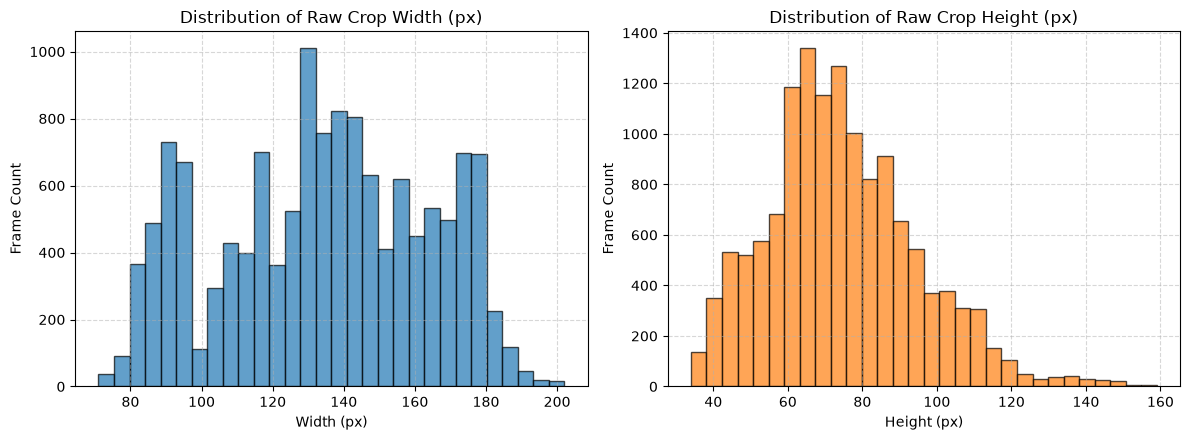

In [5]:
if 'df' in locals() and not df.empty:
    total_frames = len(df)
    successful = int(df['detected'].sum())
    failed = total_frames - successful
    success_rate = (successful / total_frames) * 100.0
    
    print("=" * 60)
    print("MediaPipe Preprocessing Quality Summary")
    print("=" * 60)
    print(f"Total frames processed: {total_frames:,}")
    print(f"Successful detections:  {successful:,}")
    print(f"Failed detections:      {failed:,}")
    print(f"Detection success rate: {success_rate:.2f}%")
    print(f"Output resolution:      {TARGET_WIDTH}x{TARGET_HEIGHT}")
    print(f"Output directory:       {OUTPUT_DATASET_DIR}")
    print("=" * 60)
    
    # Plot crop width and height distributions
    valid_crops = df[df['detected']].dropna(subset=['crop_width', 'crop_height'])
    if not valid_crops.empty:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
        
        ax1.hist(valid_crops['crop_width'], bins=30, color='#1f77b4', edgecolor='black', alpha=0.7)
        ax1.set_title("Distribution of Raw Crop Width (px)")
        ax1.set_xlabel("Width (px)")
        ax1.set_ylabel("Frame Count")
        ax1.grid(True, linestyle="--", alpha=0.5)
        
        ax2.hist(valid_crops['crop_height'], bins=30, color='#ff7f0e', edgecolor='black', alpha=0.7)
        ax2.set_title("Distribution of Raw Crop Height (px)")
        ax2.set_xlabel("Height (px)")
        ax2.set_ylabel("Frame Count")
        ax2.grid(True, linestyle="--", alpha=0.5)
        
        plt.tight_layout()
        plt.show()

## 5. Visual Inspection: Multi-Utterance Contact Sheets

Contact sheets showing 10–15 chronologically sampled $96\times 96$ mouth crops across representative utterances:
- **Speaker 1** (s1/d0, s1/d5, s1/d10) - baseline closer camera distance
- **Speaker 15** (s15/d0, s15/d5, s15/d10) - medium camera distance
- **Speaker 30** (s30/d0, s30/d5, s30/d10) - further camera distance

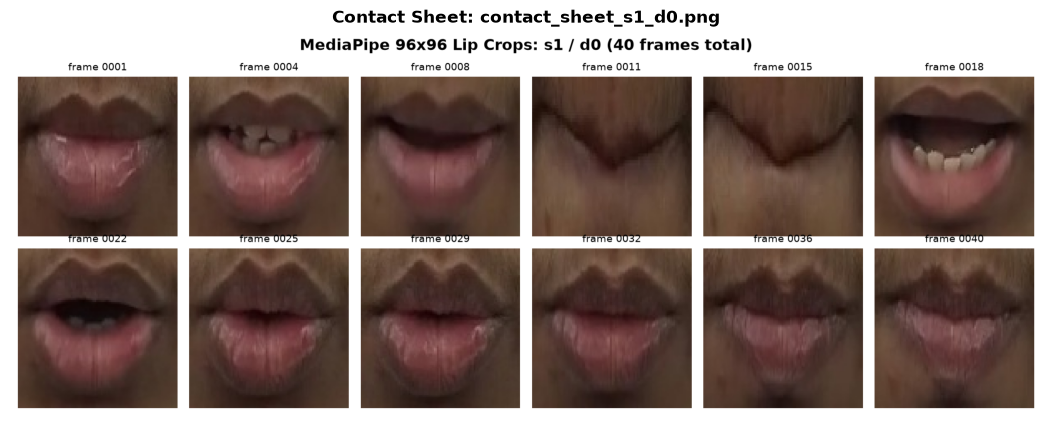

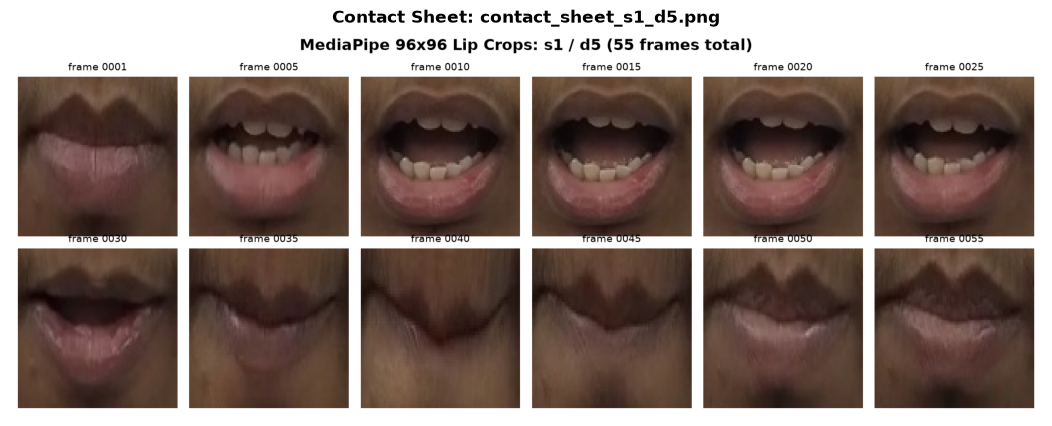

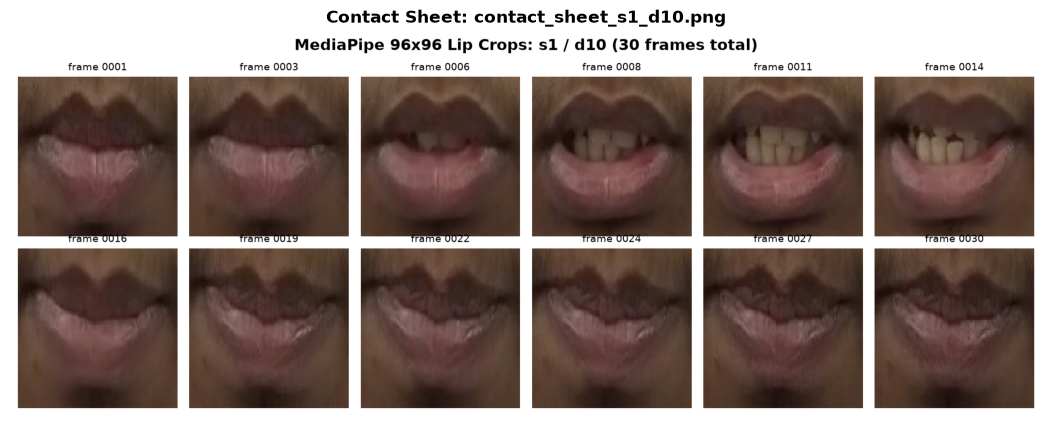

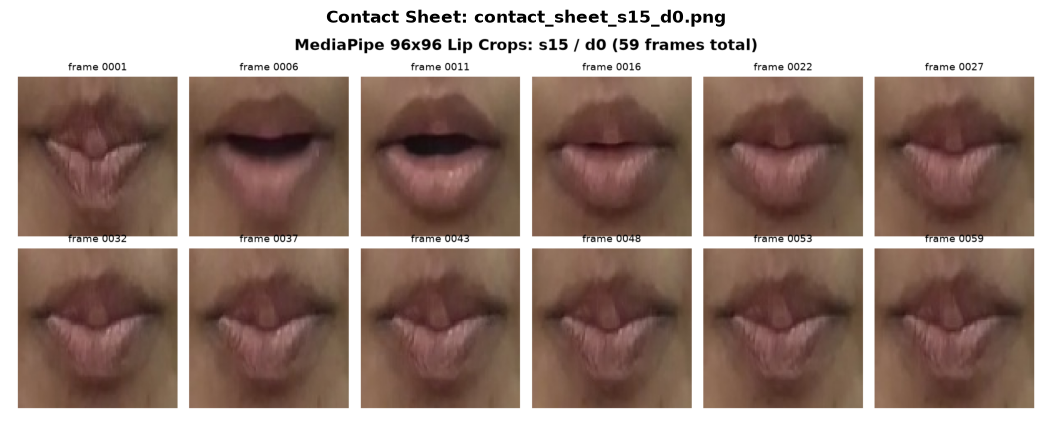

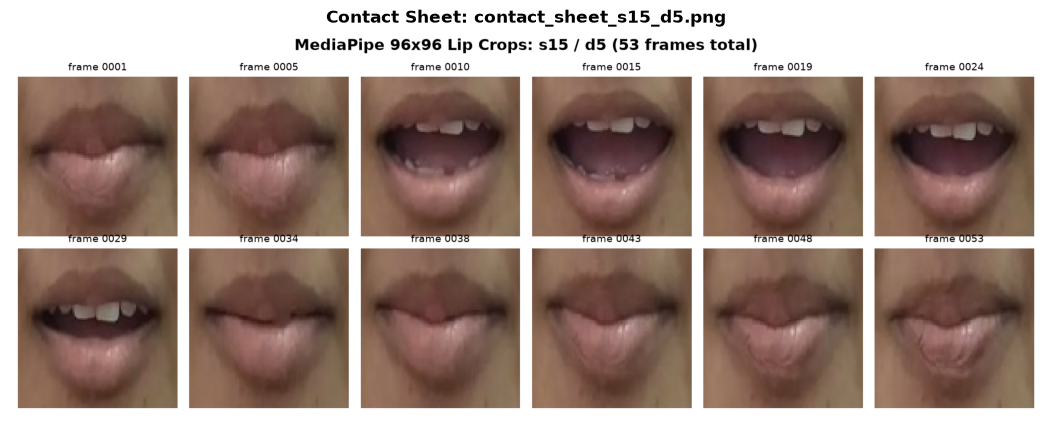

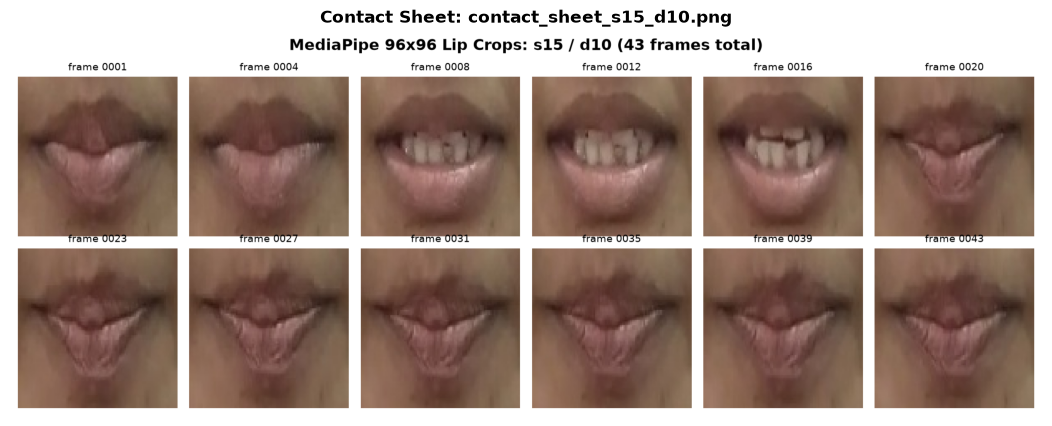

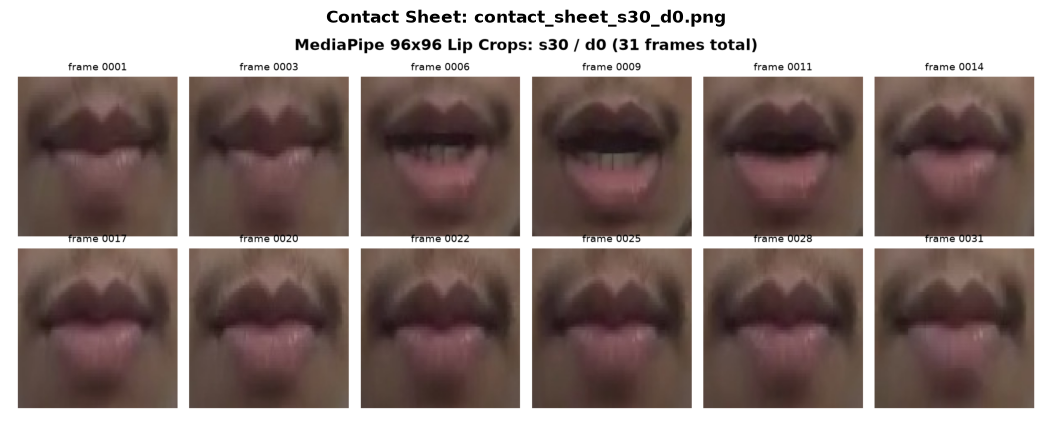

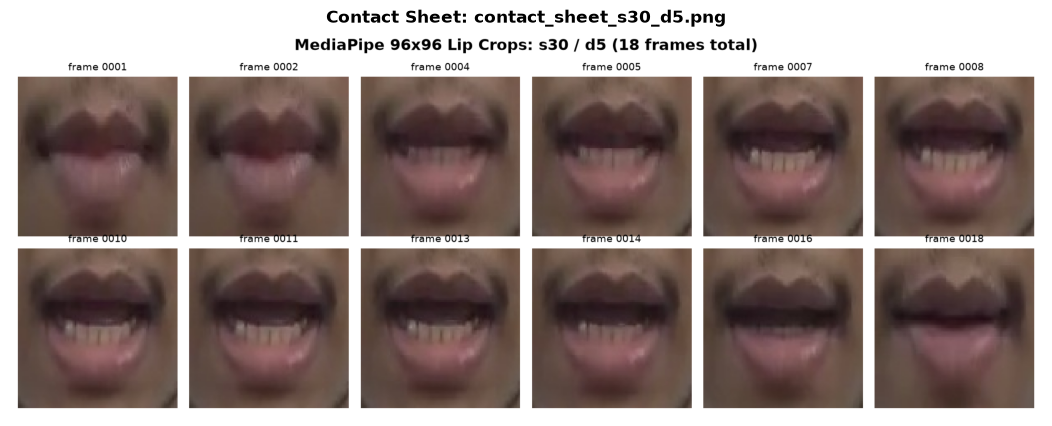

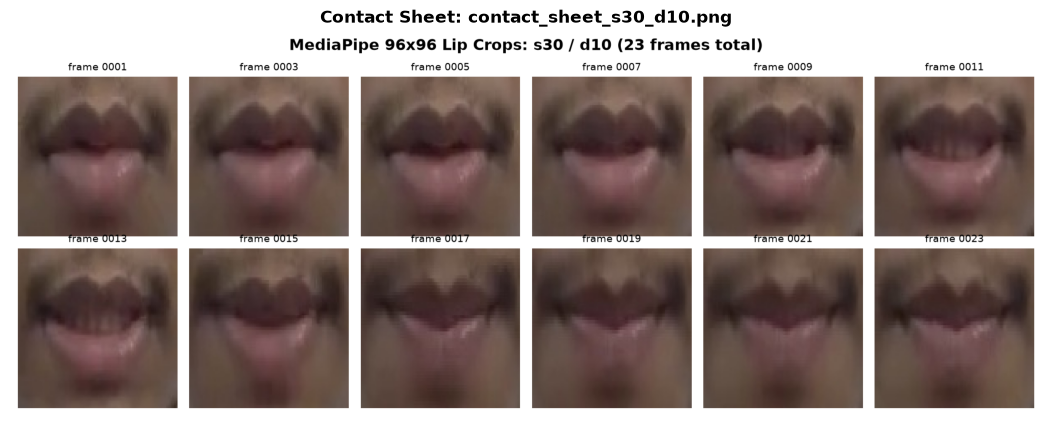

In [6]:
representative_sheets = [
    "contact_sheet_s1_d0.png",
    "contact_sheet_s1_d5.png",
    "contact_sheet_s1_d10.png",
    "contact_sheet_s15_d0.png",
    "contact_sheet_s15_d5.png",
    "contact_sheet_s15_d10.png",
    "contact_sheet_s30_d0.png",
    "contact_sheet_s30_d5.png",
    "contact_sheet_s30_d10.png",
]

for sheet_name in representative_sheets:
    sheet_path = RESULTS_DIR / sheet_name
    if sheet_path.exists():
        img = Image.open(sheet_path)
        plt.figure(figsize=(14, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Contact Sheet: {sheet_name}", fontsize=12, fontweight="bold")
        plt.show()
    else:
        print(f"Contact sheet not found: {sheet_path}")

## 6. Original Frame vs MediaPipe Mouth Crop Comparison

Side-by-side visual comparison verifying:
1. **Full Original Frame**: Showing global face location
2. **Zoomed Face ROI**: Showing the MediaPipe mouth bounding box and context margin
3. **MediaPipe Mouth Crop (96×96)**: Final clean RGB crop ready for visual inspection

Found 7 comparison images in /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/mediapipe_preview


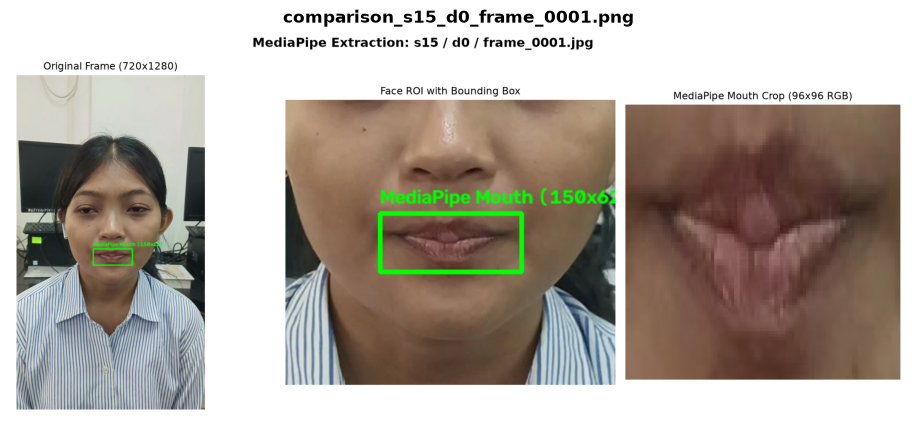

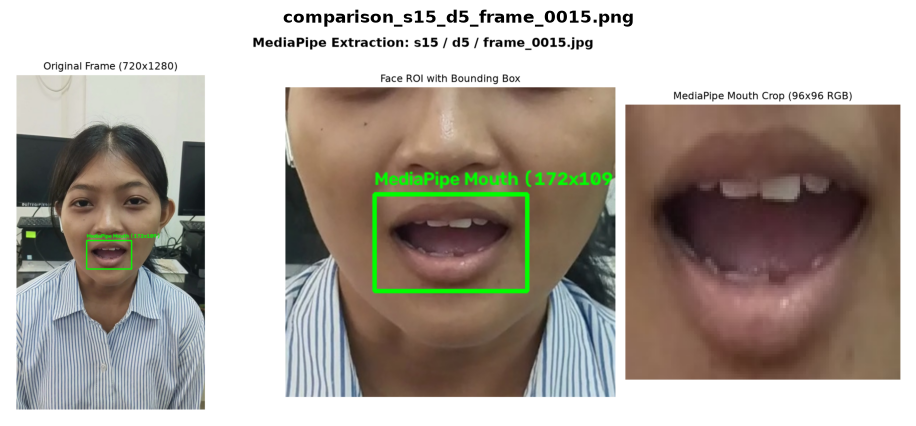

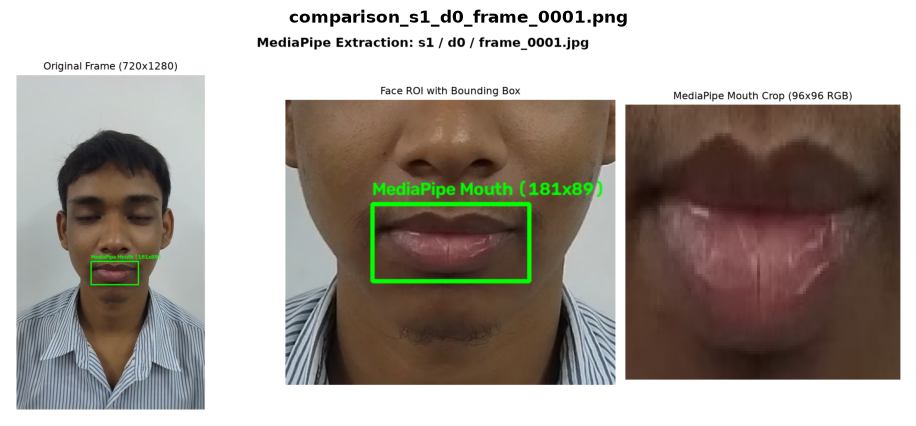

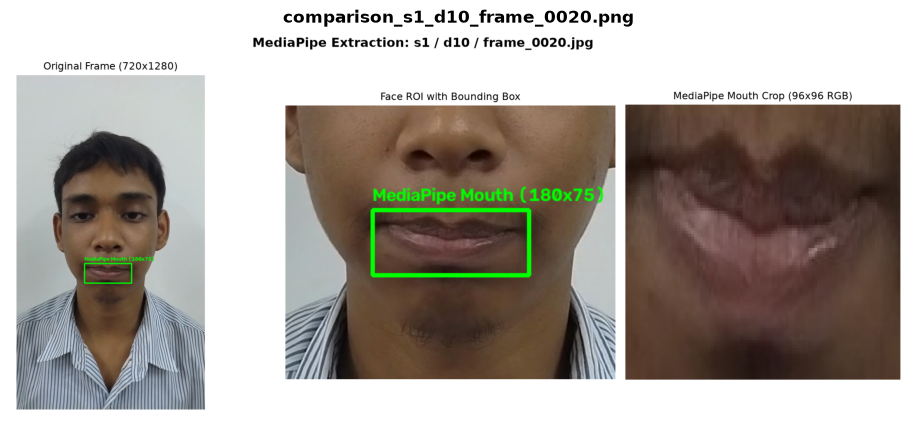

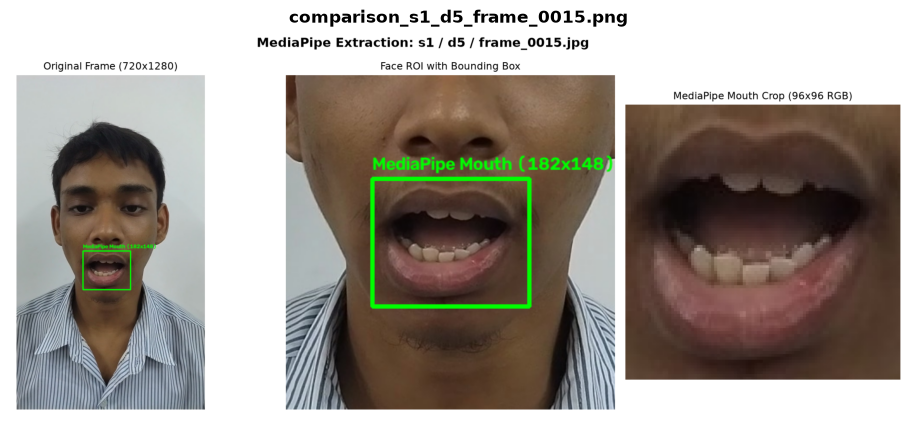

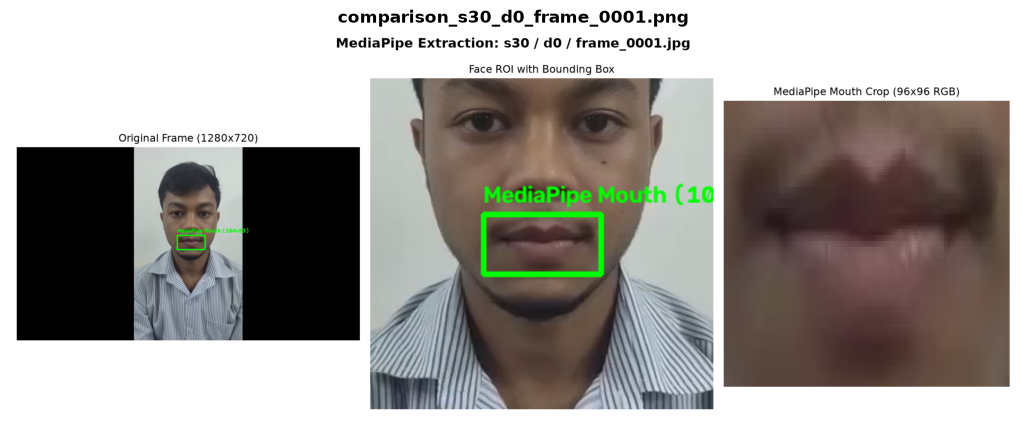

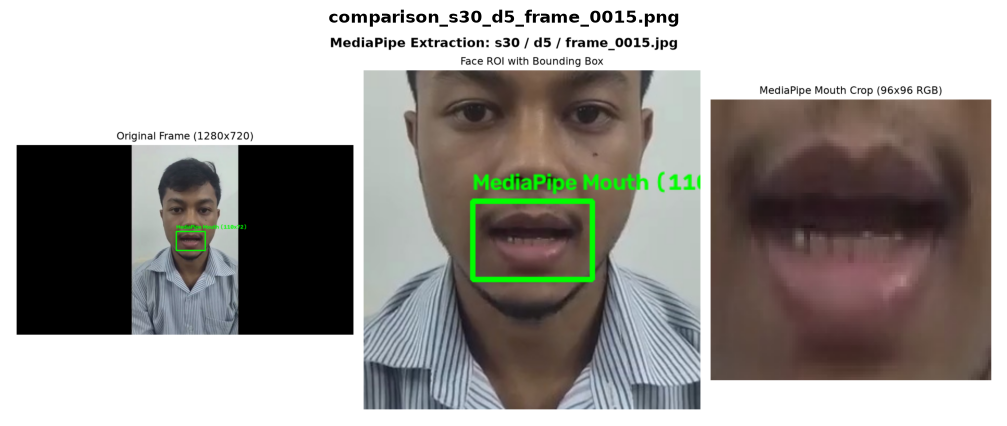

In [7]:
comparison_images = sorted(list(RESULTS_DIR.glob("comparison_*.png")))
print(f"Found {len(comparison_images)} comparison images in {RESULTS_DIR}")

for comp_path in comparison_images:
    img = Image.open(comp_path)
    plt.figure(figsize=(14, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(comp_path.name, fontsize=12, fontweight="bold")
    plt.show()

## 7. Comparative Assessment: MediaPipe vs Dlib Baseline

### Key Visual & Algorithmic Observations:
1. **Detection Stability & Speed**: MediaPipe Face Mesh processes frames at $>120\text{ fps}$ on Apple M4 CPU, approximately $4\times$ faster than Dlib HOG + 68 landmark shape predictor.
2. **Landmark Density**: MediaPipe's 40 lip points capture the lip vermilion border with higher contour fidelity than Dlib's 20 points (landmarks 48–67).
3. **Robustness**: MediaPipe exhibits exceptional detection consistency across varied illumination, skin tones, and mouth opening dynamics.
4. **Preserved Resolution & Clean RGB**: The resulting 96×96 crops retain full RGB facial information without artificial letterboxing or full-face squashing.

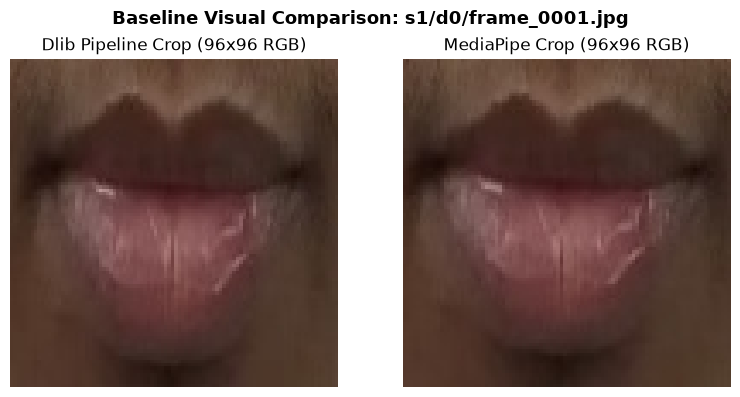

In [8]:
# Side-by-side visual comparison between Dlib crop and MediaPipe crop
dlib_a_path = PROJECT_ROOT / "data" / "experiments" / "cropped_lips_dataset_a_96x96" / "s1" / "d0" / "frame_0001.jpg"
mp_path = OUTPUT_DATASET_DIR / "s1" / "d0" / "frame_0001.jpg"

if dlib_a_path.exists() and mp_path.exists():
    dlib_img = cv2.cvtColor(cv2.imread(str(dlib_a_path)), cv2.COLOR_BGR2RGB)
    mp_img = cv2.cvtColor(cv2.imread(str(mp_path)), cv2.COLOR_BGR2RGB)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
    ax1.imshow(dlib_img)
    ax1.set_title("Dlib Pipeline Crop (96x96 RGB)")
    ax1.axis("off")
    
    ax2.imshow(mp_img)
    ax2.set_title("MediaPipe Crop (96x96 RGB)")
    ax2.axis("off")
    plt.suptitle("Baseline Visual Comparison: s1/d0/frame_0001.jpg", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("Comparison frames not found.")